In [4]:
import os
current_dir = os.getcwd()
print("Current directory:", current_dir)

Current directory: c:\Users\ashis\AppData\Local\Programs\Microsoft VS Code


In [7]:
import os
import pandas as pd

# Change to your project folder FIRST
os.chdir(r"D:\ASHISH\DATA ANALYST\PROJECTS\HR Project")
print("Current directory:", os.getcwd())

# Now load the Excel file (same folder as Jupyter notebook)
df = pd.read_excel("HR Project dataset.xlsx")
print("Dataset shape:", df.shape)          # Should show (1470, 35)
print(df.head(3))
print("Attrition rate:", df.Attrition.value_counts(normalize=True))

Current directory: D:\ASHISH\DATA ANALYST\PROJECTS\HR Project
Dataset shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                         1            80                 0   
1  ...                         4            80                 1   
2  ...                         2            80                 0   

   TotalWorkingYears 

In [3]:
import pandas as pd
df = pd.read_excel("HR Project dataset.xlsx")
# Q1: Overall attrition rate and by department
total = len(df)
attr = df["Attrition"].eq("Yes").sum()
attr_rate = attr / total
print(f"Overall attrition: {attr} out of {total} = {attr_rate:.1%}")

# By department
dept_rates = (
    df.groupby("Department")["Attrition"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)[["Yes"]]
    .sort_values("Yes", ascending=False)
)
print("\nAttrition by Department:")
print(dept_rates)

Overall attrition: 237 out of 1470 = 16.1%

Attrition by Department:
Attrition                    Yes
Department                      
Sales                   0.206278
Human Resources         0.190476
Research & Development  0.138398


In [4]:
df["AttritionNum"] = df["Attrition"].map({"Yes": 1, "No": 0})

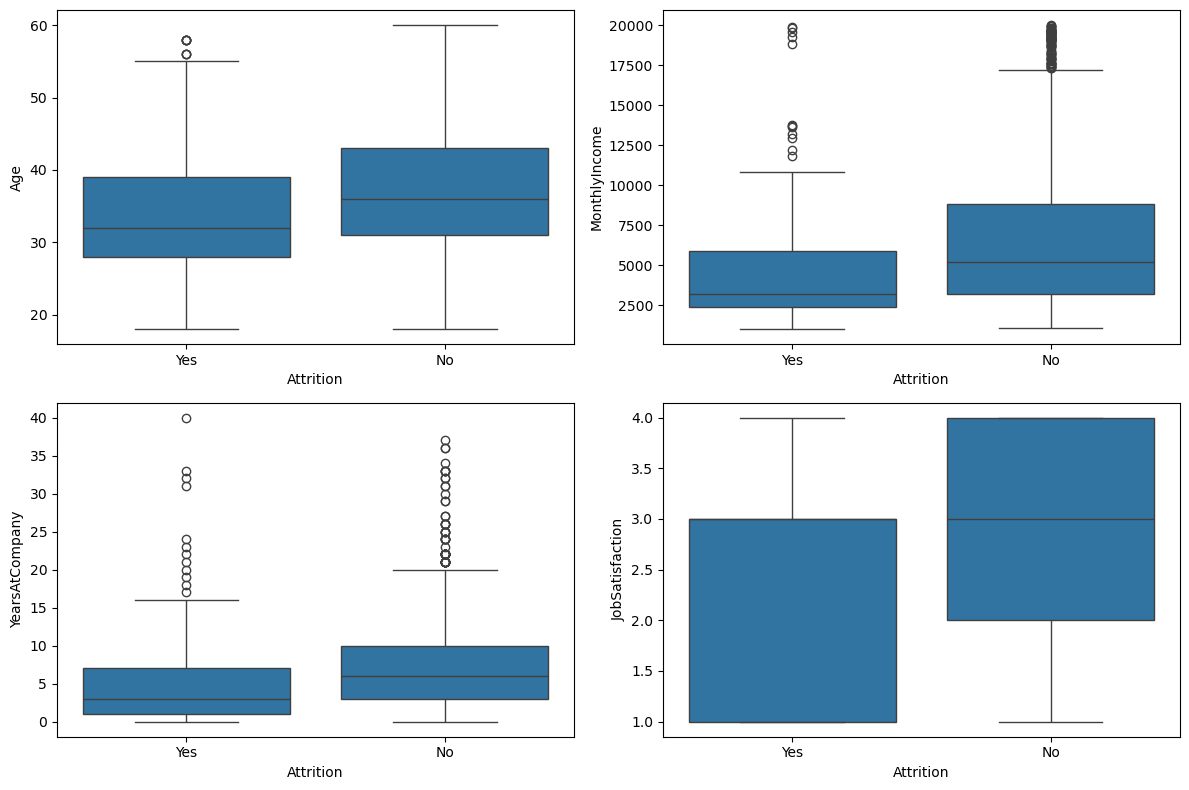

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(["Age", "MonthlyIncome", "YearsAtCompany", "JobSatisfaction"], axes.flat):
    sns.boxplot(data=df, x="Attrition", y=col, ax=ax)
plt.tight_layout()
plt.show()

In [6]:
role_attr = (
    df.groupby("JobRole")["AttritionNum"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
print(role_attr.head())

# Overtime
ovt = df.pivot_table(index="OverTime", values="AttritionNum", aggfunc="mean")
# Travel
travel = df.pivot_table(index="BusinessTravel", values="AttritionNum", aggfunc="mean")

                       count      mean
JobRole                               
Sales Representative      83  0.397590
Laboratory Technician    259  0.239382
Human Resources           52  0.230769
Sales Executive          326  0.174847
Research Scientist       292  0.160959


In [10]:
edu_income = df.groupby("Education")["MonthlyIncome"].agg(["mean", "count"]).round(0)
edu_perf = df.groupby("Education")["PerformanceRating"].agg(["mean", "count"])

print(edu_income)
print(edu_perf)

             mean  count
Education               
1          5641.0    170
2          6227.0    282
3          6517.0    572
4          6832.0    398
5          8278.0     48
               mean  count
Education                 
1          3.176471    170
2          3.170213    282
3          3.143357    572
4          3.143216    398
5          3.187500     48


In [13]:
perf_income = df.groupby("PerformanceRating")["MonthlyIncome"].agg(["mean", "count"])
print(perf_income)

                          mean  count
PerformanceRating                    
3                  6537.274116   1244
4                  6313.893805    226


In [17]:
print("Available columns:")
print([col for col in df.columns if 'Hour' in col or 'Satisfaction' in col])

Available columns:
['EnvironmentSatisfaction', 'HourlyRate', 'JobSatisfaction', 'RelationshipSatisfaction', 'StandardHours']


In [18]:
dept_sats = df.groupby("Department").agg(
    {"JobSatisfaction": "mean", "DailyRate": "mean"}
).round(2)
print("Satisfaction & Daily Rate by Department:")
print(dept_sats)

Satisfaction & Daily Rate by Department:
                        JobSatisfaction  DailyRate
Department                                        
Human Resources                    2.60     751.54
Research & Development             2.73     806.85
Sales                              2.75     800.28


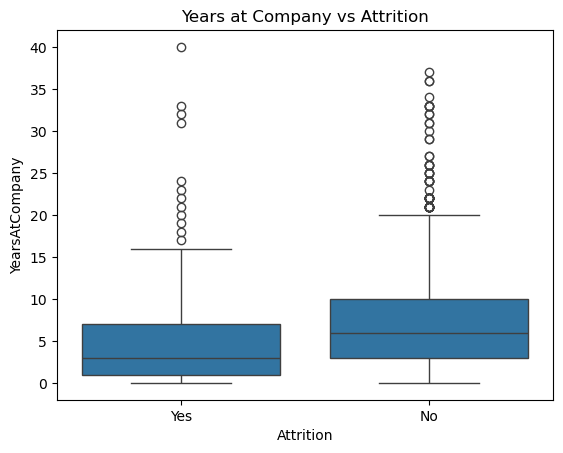

<Axes: xlabel='Attrition', ylabel='YearsWithCurrManager'>

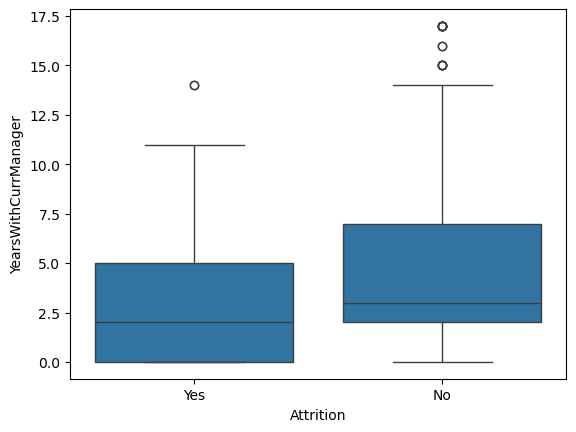

In [20]:
sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")
plt.title("Years at Company vs Attrition")
plt.show()

sns.boxplot(data=df, x="Attrition", y="YearsWithCurrManager")

In [26]:
print(df["YearsSinceLastPromotion"].value_counts())
print(df["NumCompaniesWorked"].value_counts())
print(df["OverTime"].value_counts())

YearsSinceLastPromotion
0     581
1     357
2     159
7      76
4      61
3      52
5      45
6      32
11     24
8      18
9      17
15     13
13     10
12     10
14      9
10      6
Name: count, dtype: int64
NumCompaniesWorked
1    521
0    197
3    159
2    146
4    139
7     74
6     70
5     63
9     52
8     49
Name: count, dtype: int64
OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [34]:
df["AgeGroup"] = pd.cut(df["Age"], [0, 25, 35, 50, 100])
df["IncomeBand"] = pd.cut(df["MonthlyIncome"], bins=4)

age_attr = df.groupby("AgeGroup", observed=True)["AttritionNum"].mean() * 100
income_attr = df.groupby("IncomeBand", observed=True)["AttritionNum"].mean() * 100

print(age_attr)
print(income_attr)

AgeGroup
(0, 25]      35.772358
(25, 35]     19.141914
(35, 50]      9.866221
(50, 100]    12.587413
Name: AttritionNum, dtype: float64
IncomeBand
(990.01, 5756.5]      19.661017
(5756.5, 10504.0]     14.201183
(10504.0, 15251.5]     8.695652
(15251.5, 19999.0]     3.787879
Name: AttritionNum, dtype: float64


In [35]:
combined_attr = (
    df.groupby(["AgeGroup", "IncomeBand"], observed=True)["AttritionNum"]
    .mean()
    .reset_index(name="AttritionRate")
)

combined_attr["AttritionRate"] = (combined_attr["AttritionRate"] * 100).round(2)
print(combined_attr)

     AgeGroup          IncomeBand  AttritionRate
0     (0, 25]    (990.01, 5756.5]          36.67
1     (0, 25]   (5756.5, 10504.0]           0.00
2    (25, 35]    (990.01, 5756.5]          20.93
3    (25, 35]   (5756.5, 10504.0]          16.56
4    (25, 35]  (10504.0, 15251.5]           5.00
5    (25, 35]  (15251.5, 19999.0]           0.00
6    (35, 50]    (990.01, 5756.5]          11.11
7    (35, 50]   (5756.5, 10504.0]          11.18
8    (35, 50]  (10504.0, 15251.5]          11.48
9    (35, 50]  (15251.5, 19999.0]           2.27
10  (50, 100]    (990.01, 5756.5]          17.02
11  (50, 100]   (5756.5, 10504.0]          21.74
12  (50, 100]  (10504.0, 15251.5]           5.88
13  (50, 100]  (15251.5, 19999.0]           7.69


In [36]:
#this means that younger employees with lower income have higher attrition rates, while older employees with higher income have lower attrition rates. This suggests that age and income are important factors influencing employee retention in this dataset.  

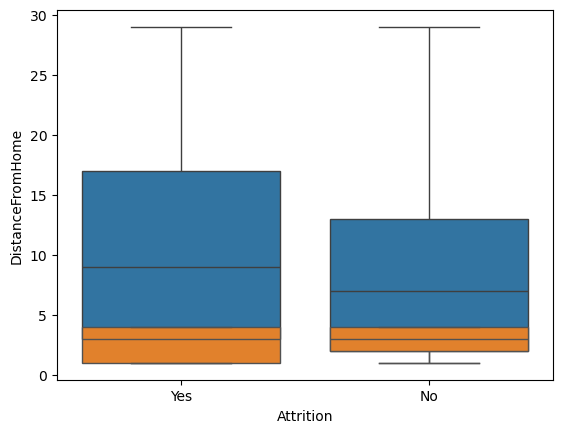

In [37]:
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
sns.boxplot(data=df, x="Attrition", y="EnvironmentSatisfaction")
plt.show()